In [1]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test (2).csv
Saving X_train.csv to X_train (2).csv
Saving y_test.csv to y_test (2).csv
Saving y_train.csv to y_train (2).csv


In [2]:
!pip install -q transformers datasets accelerate scikit-learn

In [3]:
import pandas as pd
import numpy as np
import torch

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

print(X_train.head())
print(y_train.head())
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

                                            headline
0                                   fbi raids fridge
1          old el paso introduces emergency taco kit
2  larry kudlow 'leaning' toward senate run in co...
3  'everything's $10,000' chain goes out of business
4  what this ceo did proves that introverts make ...
   is_sarcastic
0             1
1             1
2             0
3             1
4             0
(21367, 1) (5342, 1) (21367, 1) (5342, 1)


In [5]:
train_texts = X_train["headline"].tolist()
test_texts = X_test["headline"].tolist()

train_labels = y_train["is_sarcastic"].tolist()
test_labels = y_test["is_sarcastic"].tolist()

print(train_texts[:3])
print(train_labels[:3])

['fbi raids fridge', 'old el paso introduces emergency taco kit', "larry kudlow 'leaning' toward senate run in connecticut"]
[1, 1, 0]


In [6]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [7]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=64
)

In [9]:
class SarcasmDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


In [10]:
train_dataset = SarcasmDataset(train_encodings, train_labels)
test_dataset = SarcasmDataset(test_encodings, test_labels)

In [11]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.273241,0.204897,0.921939,0.904362,0.919403,0.911821
2,0.102007,0.259794,0.931486,0.932285,0.910021,0.921019
3,0.032902,0.359036,0.932984,0.928787,0.917697,0.923209


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4008, training_loss=0.1360499340141129, metrics={'train_runtime': 506.6327, 'train_samples_per_second': 126.524, 'train_steps_per_second': 7.911, 'total_flos': 1061411590156032.0, 'train_loss': 0.1360499340141129, 'epoch': 3.0})

In [16]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 0.3590361475944519,
 'eval_accuracy': 0.932983901160614,
 'eval_precision': 0.9287872248597324,
 'eval_recall': 0.9176972281449893,
 'eval_f1': 0.9232089232089232,
 'eval_runtime': 6.8403,
 'eval_samples_per_second': 780.96,
 'eval_steps_per_second': 48.828,
 'epoch': 3.0}

In [17]:
pred_output = trainer.predict(test_dataset)
preds = np.argmax(pred_output.predictions, axis=1)

pred_df = pd.DataFrame({
    "headline": test_texts,
    "actual": test_labels,
    "predicted": preds
})

pred_df.head()

,headline,actual,predicted
0,the outsider has officially squeezed its way i...,0,0
1,lgbtq activists organizing massive dance prote...,0,0
2,"romney dominated debate, say pundits trying to...",1,1
3,israeli soldiers open fire on palestinians car...,1,0
4,learned sage points out that powerball not as ...,1,1


In [18]:
misclassified = pred_df[pred_df["actual"] != pred_df["predicted"]]
misclassified.head(10)

,headline,actual,predicted
3,israeli soldiers open fire on palestinians car...,1,0
7,americans finally found something to drink tha...,0,1
8,that show about the lady sheriff finally relea...,1,0
62,stepmom doesn't expect kids to call her stupid...,1,0
66,'fire rainbow' supplants double rainbow as soc...,0,1
103,former presidents convene for liver spot summit,1,0
105,twitter creator on iran: 'i never intended for...,1,0
120,controversial photo-editing app under fire for...,0,1
131,u.s. military prepares for biggest okinawa lan...,0,1
161,police finally make breakthrough in decades-ol...,1,0


In [19]:
correct = pred_df[pred_df["actual"] == pred_df["predicted"]]
correct.head(10)

,headline,actual,predicted
0,the outsider has officially squeezed its way i...,0,0
1,lgbtq activists organizing massive dance prote...,0,0
2,"romney dominated debate, say pundits trying to...",1,1
4,learned sage points out that powerball not as ...,1,1
5,all about otters!,0,0
6,mitt romney jots down ideas for concession spe...,1,1
9,shamed and abandoned: the fate of syria's form...,0,0
10,women leaders talk personal: how to be a true ...,0,0
11,survival myths that could actually kill you,0,0
12,letter from employer thankfully omits balls-co...,1,1


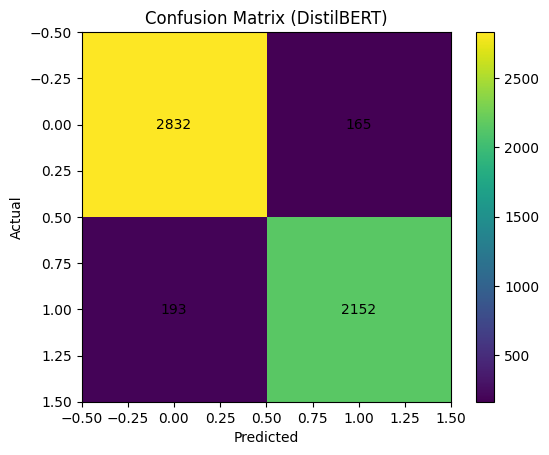

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(pred_df["actual"], pred_df["predicted"])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (DistilBERT)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [25]:
pred_df.to_csv("bert_predictions.csv", index=False)

In [26]:
metrics_df = pd.DataFrame([eval_results])
metrics_df.to_csv("bert_eval_results.csv", index=False)

In [27]:
from google.colab import files

files.download("bert_predictions.csv")
files.download("bert_eval_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>